# SeqOptPlot.hypervolume — convergence trace\n\nThe per-generation hypervolume of the front (`SeqOpt.trajectory_`) is non-decreasing under `(mu+lambda)` elitism on a fixed seed — the optimization advancing each generation.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False

# Gamma-secretase (GSEC) substrate data + the bundled interpretable CPP feature set.
df_feat = aa.load_features(name="DOM_GSEC")           # 150 CPP features (with positions, feat_importance)
df_seq  = aa.load_dataset(name="DOM_GSEC", n=50)      # 100 TMD sequences, label 1 = GSEC substrate
labels  = df_seq["label"].to_list()

# A simple RandomForest substrate classifier on the CPP feature matrix.
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=df_feat["feature"],
                                 df_parts=sf.get_df_parts(df_seq=df_seq),
                                 df_scales=aa.load_scales()), dtype=float)
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X, labels)

# Pick a NON-substrate as the wild-type and design a "super substrate": mutate its TMD to
# maximize the predicted substrate probability with as few mutations as possible.
wt = df_seq[df_seq["label"] == 0].iloc[[0]].reset_index(drop=True)
objectives = [("substrate", "max", "delta_pred"),     # raise P(GSEC substrate) (RF prediction shift)
              ("parsimony", "min", "n_mut")]          # with as few mutations as possible


In [2]:
seqopt = aa.SeqOpt(mode="importance", model=model, target_class=1, random_state=42)
df_pareto = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives,
                       algorithm="nsga2", pop_size=40, n_gen=20, n_mut_max=5, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)


DataFrame shape: (7, 8)


,entry,variant,n_mut,sequence_mut,substrate,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0,inf
2,Q14802,L37T+I55T+V56L+S58Q+A59R,5,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,37.000000,5.000000,0,inf
3,Q14802,L37G+A59R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,29.000000,2.000000,0,0.429730
4,Q14802,A59R,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,16.000000,1.000000,0,0.316216
5,Q14802,L37G+V56L+A59R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,33.000000,3.000000,0,0.281081
6,Q14802,A59K,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,16.000000,1.000000,0,0.275676
7,Q14802,L37G+V56L+S58Q+A59R,4,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,35.000000,4.000000,0,0.254054


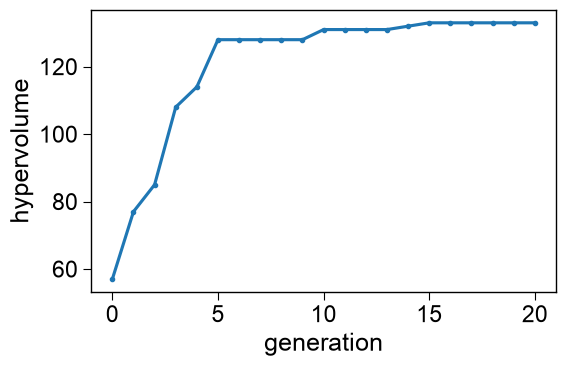

In [3]:
aa.plot_settings()
aa.SeqOptPlot().hypervolume(trajectory=seqopt.trajectory_)
plt.tight_layout(); plt.show()